# Baseline DenseNet

- DenseNet121, no pretrained weights
- Simple linear classifier head
- No class weighting
- BCEWithLogitsLoss, Adam optimizer

### 1. Import Libraries

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.densenet_baseline import DenseNetBaseline
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

### 2. Use Cuda

In [2]:
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


### 3. Load dataset

- Use DenseNetBaseline model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

model = DenseNetBaseline().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

c:\Users\lydia\Desktop\SUTD\50.039-Deep-Learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lydia\Desktop\SUTD\50.039-Deep-Learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


### 4. Train Model

In [5]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

Epoch [1/20] | Train Loss: 0.3492, Train Acc: 0.8498 | Val Loss: 0.2930, Val Acc: 0.8610
Epoch [2/20] | Train Loss: 0.2951, Train Acc: 0.8664 | Val Loss: 0.3038, Val Acc: 0.8653
Epoch [3/20] | Train Loss: 0.2796, Train Acc: 0.8765 | Val Loss: 0.2893, Val Acc: 0.8713
Epoch [4/20] | Train Loss: 0.2685, Train Acc: 0.8776 | Val Loss: 0.2856, Val Acc: 0.8645
Epoch [5/20] | Train Loss: 0.2600, Train Acc: 0.8863 | Val Loss: 0.2797, Val Acc: 0.8747
Epoch [6/20] | Train Loss: 0.2568, Train Acc: 0.8852 | Val Loss: 0.2562, Val Acc: 0.8832
Epoch [7/20] | Train Loss: 0.2463, Train Acc: 0.8929 | Val Loss: 0.2679, Val Acc: 0.8798
Epoch [8/20] | Train Loss: 0.2444, Train Acc: 0.8924 | Val Loss: 0.2552, Val Acc: 0.8824
Epoch [9/20] | Train Loss: 0.2355, Train Acc: 0.9002 | Val Loss: 0.2577, Val Acc: 0.8900
Epoch [10/20] | Train Loss: 0.2394, Train Acc: 0.8951 | Val Loss: 0.2782, Val Acc: 0.8747
Epoch [11/20] | Train Loss: 0.2295, Train Acc: 0.9011 | Val Loss: 0.2558, Val Acc: 0.8951
Epoch [12/20] | Tra

### 5. Plot Loss and Accuracy Curves

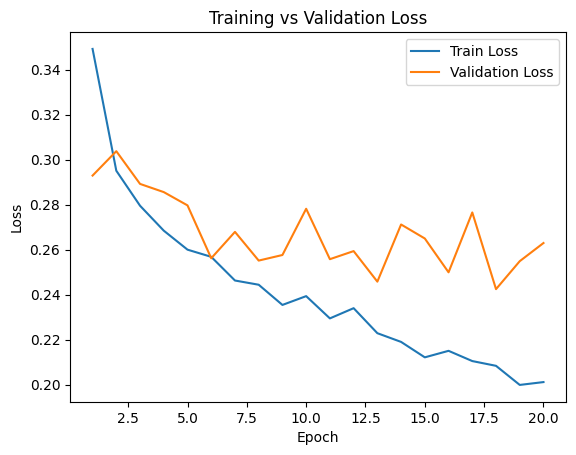

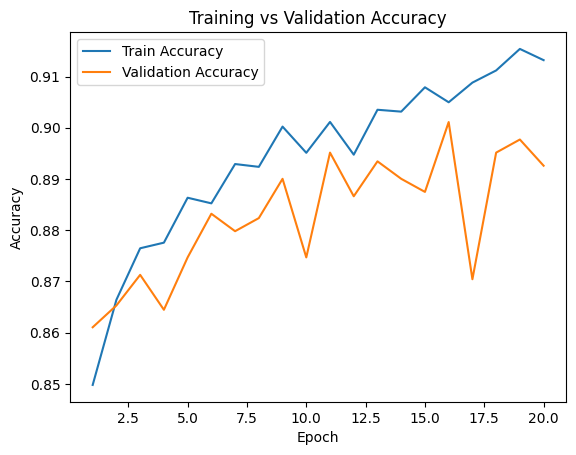

In [6]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model

[[TN, FP],<br/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → "When the model says YES, how often is it correct?"<br/>
Recall → "Out of all actual YES, how many did we catch?"

In [7]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.5)                       # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[964  42]
 [ 82  85]]
              precision    recall  f1-score   support

           0     0.9216    0.9583    0.9396      1006
           1     0.6693    0.5090    0.5782       167

    accuracy                         0.8943      1173
   macro avg     0.7954    0.7336    0.7589      1173
weighted avg     0.8857    0.8943    0.8881      1173



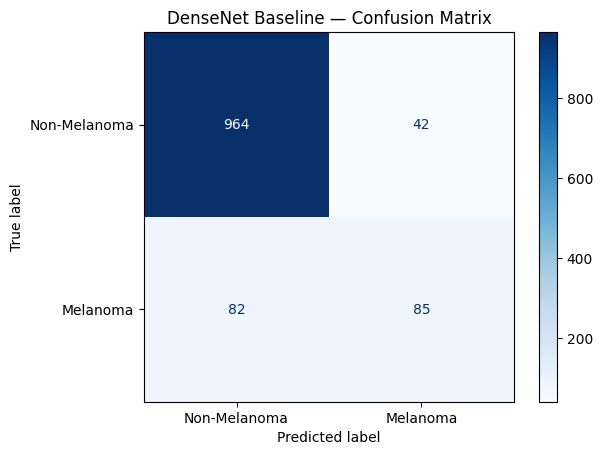

In [8]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("DenseNet Baseline — Confusion Matrix")
plt.show()